# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
We use these models because real data isn’t always nicely linear or continuous. Logistic-type models let us deal with probabilities and categories instead of just predicting any number. Linear regression can give weird outputs like probabilities above 1, so this fixes that.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross entropy works well because it punishes the model more when it’s confidently wrong. That forces it to not just guess the right class, but actually learn good probability estimates.

3. True or false, and explain: Logistic regression is a linear model.

True, kind of. It’s linear in how it combines the features, but then it runs that through a sigmoid, so the final output isn’t linear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is literally made for classification. You just turn the probability into a class using a threshold.


5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Not really. The coefficient tells you how the log-odds change, not the probability directly. The probability shift depends on where you are on the curve.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. You still need feature engineering. The model itself is basically linear in the inputs, so it won’t magically capture complex patterns on its own.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. It’s not just a better version of linear regression. It’s better for classification, but if you’re predicting continuous values, linear regression is still the right tool.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?
Debtor has a positive effect, so students with debt are more likely to drop out. Tuition fees up to date has a strong negative effect, which means being up to date really lowers dropout risk. Scholarship holder is also negative, so scholarships help reduce dropout. Age has a small positive effect, meaning older students are slightly more at risk. Yes, being up to date on tuition clearly reduces dropout risk.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

From the plot, students who are not up to date on tuition consistently have much higher dropout probabilities across all ages. The difference is pretty noticeable everywhere, not just for a specific age group. On average, the predicted dropout probability drops from about 0.86 to 0.25, so being up to date lowers it by roughly 0.61, which is a big change.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The model has an accuracy of about 76%. It does a good job predicting students who won’t drop out, but it misses a decent number of actual dropouts, so it’s not perfect at catching high-risk students.


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

The logistic model keeps predictions between 0 and 1, which makes sense for probabilities. The linear model sometimes goes outside that range, so it’s less reliable here. Overall, logistic regression gives more realistic predictions for this kind of problem.


5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The most at-risk students are those with debt, not up to date on tuition, and without scholarships. Older students also seem slightly more at risk. Some reasonable interventions would be financial support, payment plans, or helping students stay on track academically through advising or tutoring.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

The hard predictions don’t cover every class well. In fact, the model never predicts one of the classes at all, which shows it’s biased toward certain outcomes. But when you look at predicted probabilities, the model still assigns values to all classes. So even though it doesn’t always pick every class as the final answer, it still “considers” them.


In [1]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 14.11 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [3]:
import pandas as pd

# load with correct delimiter
df = pd.read_csv("data.csv", sep=";")

# keep only needed columns
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols]

# drop missing values (simple approach)
df = df.dropna()

# create binary target (1 = dropout, 0 = not)
df["dropout"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

In [4]:
from sklearn.linear_model import LogisticRegression

X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# coefficients
coef = pd.Series(model.coef_[0], index=X.columns)
print(coef)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


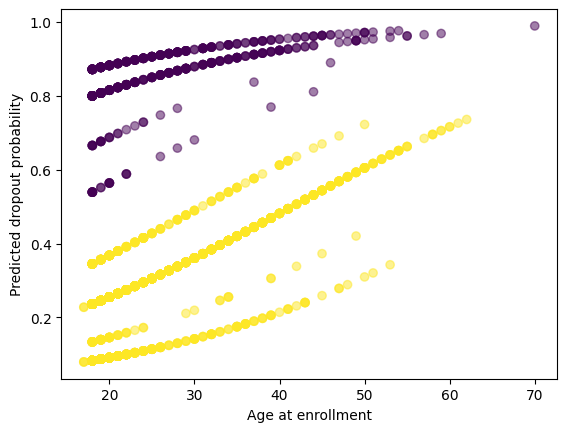

In [5]:
import matplotlib.pyplot as plt

df["prob"] = model.predict_proba(X)[:, 1]

plt.scatter(df["Age at enrollment"], df["prob"],
            c=df["Tuition fees up to date"], alpha=0.5)
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.show()

In [6]:
df.groupby("Tuition fees up to date")["prob"].mean()

,prob
Tuition fees up to date,
0,0.860675
1,0.248090


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print(acc)

[[2841  162]
 [ 891  530]]
0.7619801084990958


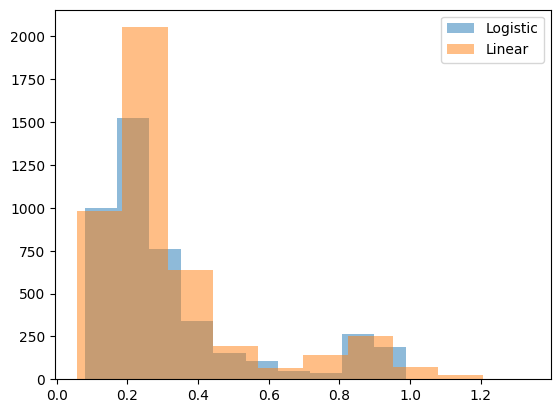

In [8]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df["lin_prob"] = lin.predict(X)

plt.hist(df["prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi.fit(X_multi, y_multi)

preds = multi.predict(X_multi)
probs = multi.predict_proba(X_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_multi, preds))

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The drug has a small positive effect on survival, so it seems to slightly improve survival probability compared to placebo. Bilirubin has a negative effect, meaning higher bilirubin is associated with lower survival. Edema also reduces survival, and the effect is stronger for more severe edema, so worse swelling is linked to lower survival rates.


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

Survival probability decreases pretty clearly as bilirubin increases. Patients with low bilirubin tend to have high survival probabilities, while those with high bilirubin are close to zero. The drug gives a small boost in survival across most bilirubin values, but both groups follow the same downward trend. Overall, bilirubin has a much stronger impact than the drug.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


The model has an accuracy of about 73.7%. It predicts survival reasonably well, but it struggles more with correctly identifying deaths, so there are still some noticeable errors.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

The logistic model keeps predictions between 0 and 1, which makes sense for probabilities. The linear model produces some values outside this range (like negatives), which aren’t realistic. Because of that, logistic regression performs better for this problem.


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

The model does not predict every stage. It mostly predicts the later stages and completely misses some of the earlier ones, so the hard classification is clearly biased. However, the predicted probabilities still assign values to all stages, even if the final prediction doesn’t pick them. So the model is capturing information about every class, just not reflecting it well in the final predictions.

In [11]:
from google.colab import files
uploaded = files.upload()

Saving cirrhosis.csv to cirrhosis.csv


In [12]:
import pandas as pd

df = pd.read_csv("cirrhosis.csv")

# keep relevant columns
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

# drop missing values
df = df.dropna()

# binary target: 1 = alive, 0 = dead
df["alive"] = df["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)

# one-hot encode categorical variables
df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

In [13]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Status", "alive", "Stage"])
y = df["alive"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coef = pd.Series(model.coef_[0], index=X.columns)
print(coef)

Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64


In [14]:
import matplotlib.pyplot as plt

df["prob"] = model.predict_proba(X)[:, 1]

plt.scatter(df["Bilirubin"], df["prob"],
            c=df["Drug_D-penicillamine"], alpha=0.5)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.show()

KeyError: 'Drug_D-penicillamine'

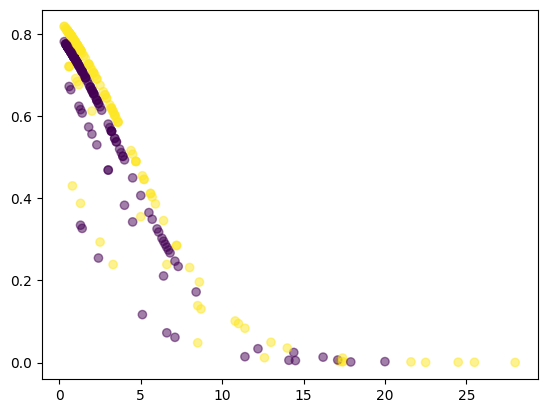

In [15]:
drug_col = [col for col in df.columns if "Drug" in col][0]

plt.scatter(df["Bilirubin"], df["prob"],
            c=df[drug_col], alpha=0.5)

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print(acc)

[[ 59  66]
 [ 16 171]]
0.7371794871794872


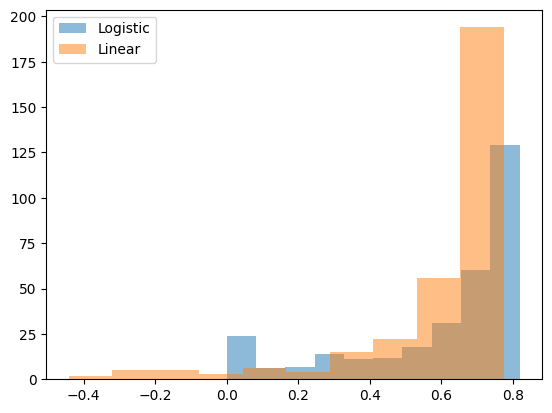

In [17]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df["lin_prob"] = lin.predict(X)

plt.hist(df["prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

In [18]:
X_stage = df.drop(columns=["Status", "alive", "Stage"])
y_stage = df["Stage"]

from sklearn.linear_model import LogisticRegression
multi = LogisticRegression(max_iter=1000)
multi.fit(X_stage, y_stage)

preds = multi.predict(X_stage)
probs = multi.predict_proba(X_stage)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_stage, preds))

[[ 0  0 15  1]
 [ 0  0 60  7]
 [ 0  0 98 22]
 [ 0  0 65 44]]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

The derivative with respect to $x_k$ is $b_k$. So if $x_k$ increases by 1, the prediction increases by $b_k$. This effect is constant and does not depend on $x$.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

The derivative is $b_k \cdot \hat{p}(1 - \hat{p})$. Unlike the linear model, this depends on $\hat{p}$, so the effect changes depending on the input. The effect is largest when $\hat{p}$ is around 0.5, since $\hat{p}(1 - \hat{p})$ is maximized there. Around that point, $b_k$ (times 4) is a reasonable approximation of the change.

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

A 1 unit increase in $x_k$ increases the log-odds by $b_k$. This relationship is linear and constant, even though the probability itself is not.